In [76]:
from fairchem.core.preprocessing import AtomsToGraphs
from fairchem.core.datasets import LmdbDataset

from pymatgen.core import Lattice, Structure, Molecule
from pymatgen.io.ase import AseAtomsAdaptor

from ase import Atoms

import matplotlib.pyplot as plt
import seaborn as sns

import lmdb
import pickle
from tqdm import tqdm
import torch
import os, shutil
import spglib

import json
import numpy as np
import pandas as pd
import ast

In [77]:
# functions used to convert dataframe row to pymatgen object
def str_to_2d_array(string):
    '''
    The object in panda dataframe is string format.
    Convert to numpy array.
    '''
    if ',' not in string:
        string = string.replace(' ', ',')
    try:
        list_of_lists = ast.literal_eval(string)
        return np.array(list_of_lists)
    except ValueError:
        return None

def symmetrize_structure(structure, symprec=0.001):
    '''
    convert non-premitive to premitive
    '''
    cell = (structure.lattice.matrix, structure.frac_coords, structure.atomic_numbers )
    try:
        lattice, scaled_positions, numbers = spglib.standardize_cell(cell, 
                                                                     to_primitive=True, 
                                                                     no_idealize=False, 
                                                                     symprec=symprec)
        spacegroup_symbol = spglib.get_spacegroup(cell, symprec=symprec)
        # return Atoms(numbers=numbers,cell=lattice,scaled_positions=scaled_positions), spacegroup_symbol
        return Structure(Lattice(lattice), numbers, scaled_positions), spacegroup_symbol
    except:
        return structure, None

def get_structure(system):
    '''
    system: pandas.Series of one compound (one row of pd.dataframe).
    return pymatgen Structure object.
    '''
    cell = str_to_2d_array(system['cell'])
    posi = str_to_2d_array(system['positions'])    
    atom = str_to_2d_array(system['numbers'] )
    
    lattice = Lattice(cell)
    structure = Structure(lattice, atom, posi)
    structure,_ = symmetrize_structure(structure)

    return structure

In [78]:
# convert panda dataframe to list of ASE atoms object.
def db_to_atomslist(compounds_df, properties={"UUID": "UUID"}):
    '''
    compounds_df: panda dataframe contains compound name, cell vectors, atom positions, atom numbers, and target property
    properties: dictionary that contains {name for following training: name in compounds_df}
    '''

    atoms_list = []
    for ind,row in tqdm(compounds_df.iterrows(), total=compounds_df.shape[0]):
    # loop over panda dataframe of the dataset
        
        struc = get_structure(row)                # convert row to pymatgen structure format    
        atoms = AseAtomsAdaptor.get_atoms(struc)  # convert to ASE atoms format
    
        # pass information to the ASE atoms object 
        atoms.info['id']    = ind                  
        for key, item in properties.items():
            atoms.info[key]  = row[item]          
    
        atoms_list.append(atoms)
    return atoms_list
print(len(atoms_list))

2000


In [79]:
# function used to split dataset to train/valid/test 
def split_dataset(atoms_list, ratio = [0.8, 0.1, 0.1], seed=None):
    '''
    split the datase to train/vaild/test set by ratio.
    '''
    
    N   = len(atoms_list)
    ratio = np.array(ratio)
    ratio /= ratio.sum()    

    train_end = int(N * ratio[0])
    val_end   = train_end + int(N * ratio[1])
    
    ids = np.arange(N)
    rng = np.random.default_rng(seed=seed)
    rng.shuffle(ids)
    
    split_set = {}
    split_set['train']=[]
    split_set['val']=[]
    split_set['test']=[]
    for ind in ids[0:train_end]:
        split_set['train'].append(atoms_list[ind])
    for ind in ids[train_end:val_end]:
        split_set['val'].append(atoms_list[ind])
    for ind in ids[val_end:]:
        split_set['test'].append(atoms_list[ind])

    return split_set

In [177]:
# this fucntion converts the train/val/test set to lmdb database for 
# training process 

def split_set_to_lmdb(split_set, properties, dir_name):
    '''
    convert the split_set to lmdb database.
    ...
    '''
    # the parser from ASE atoms to graph
    a2g = AtomsToGraphs(
        r_energy=False,    
        r_forces=False,    
        r_distances=True,
        r_fixed=True,
        r_pbc=True,
        r_data_keys=['id'] + list(properties.keys())
    )

    # remove folder if it exists
    if os.path.exists(dir_name):
        shutil.rmtree(dir_name)
    
    # create new empty folder
    os.makedirs(dir_name)

    # create lmdb database for train/val/test
    for db_name in split_set.keys():
        raw_data = split_set[db_name]
    
        db = lmdb.open(
            f"{dir_name}/{db_name}.lmdb",
            map_size=1099511627776 * 2,
            subdir=False,
            meminit=False,
            map_async=True,
        )
    
        data_objects = a2g.convert_all(raw_data, disable_tqdm=True)
        
        for fid, data in tqdm(enumerate(data_objects), total=len(data_objects)):
            # assign sid
            data.sid = torch.LongTensor([0])
        
            # assign fid
            data.fid = torch.LongTensor([fid])
        
            # check whether it is no neighbor edge case 
            if data.edge_index.shape[1] == 0:
                print("no neighbors", traj_path)
                continue
        
            txn = db.begin(write=True)
            txn.put(f"{fid}".encode("ascii"), pickle.dumps(data, protocol=-1))
            txn.commit()
        
        txn = db.begin(write=True)
        txn.put(f"length".encode("ascii"), pickle.dumps(len(data_objects), protocol=-1))
        txn.commit()
            
        db.sync()
        db.close()

## Make data for examples

In [178]:
d = pd.read_csv('../../../database/DXMag_heusler_20241229_updated.csv', index_col=0, low_memory=False)
d = d[d['most stable']==True]
print(d.shape)
d = d[d['total magnetization (muB/f.u.)'] > 0.1 ]
print(d.shape)

d = d.sample(4000).copy()
cols = ['composition',  'UUID',
        'cell', 'positions', 'numbers', 
        'energy (eV/atom)', 'formation energy (eV/atom)', 'hull distance (eV/atom)',
        'total magnetization (muB/f.u.)',  'band gap (eV)']

d = d[cols]
# print(d.shape)
# d.head(2000).to_csv('database_example_train.csv')
# d.tail(2000).iloc[:,:5].to_csv('database_example_apply.csv')

(27864, 76)
(7845, 76)


## Generate lmdb sets for train\valid\test for training purpose

In [179]:
compounds_df = pd.read_csv('./database_example_train.csv', index_col=0, )

In [180]:
# this block convert information in database to a list of ASE atoms
properties = {
    "UUID": "UUID",
    "Form": "formation energy (eV/atom)",
    "Hull": "hull distance (eV/atom)",
    "Mtot": "total magnetization (muB/f.u.)"
}
# properties is dictionary that contains {name used in following training: name in compounds_df}

atoms_list = db_to_atomslist(compounds_df, properties=properties)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:04<00:00, 433.02it/s]


In [181]:
# this block split atoms_list to train/valid/test sets
split_set = split_dataset(atoms_list, ratio = [0.8, 0.1, 0.1])

# split the datase to train/vaild/test set by ratio

In [182]:
# print info of the split_set
print(f"{'set name':<15}{'set size':>10}")
print("-" * 25)
for key, item in split_set.items():
    print(f"{key:<15}{len(item):>10}")
    

set name         set size
-------------------------
train                1600
val                   200
test                  200


In [183]:
# convert splitted sets of train/val/test to lmdb databases.
# properties is the same as before.
# dir_name is where lmdb databases stored.

split_set_to_lmdb(split_set, properties, dir_name='set_example_train')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 3744.56it/s]


## Check distribution of train/val/test sets
The mean and std values of train set is useful to set the normalization in the input file of train process.

Mean:     0.1420
Std Dev:  0.3515
Min:      -0.8960
Max:      1.4653


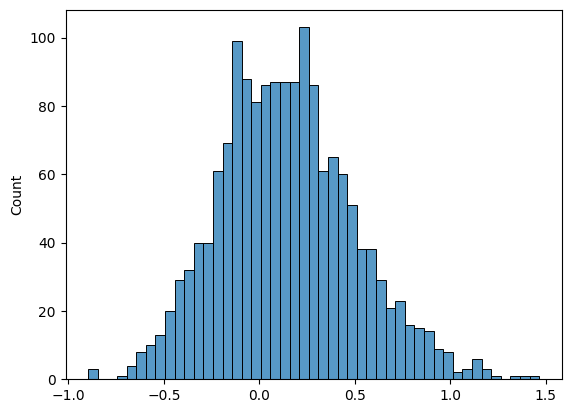

In [184]:
dataset = LmdbDataset({"src": "set_example_train/train.lmdb"})
db = [data['Form'] for data in dataset]
sns.histplot(db, binwidth=0.05)

print(f"{'Mean:':<10}{np.mean(db):.4f}")
print(f"{'Std Dev:':<10}{np.std(db):.4f}")
print(f"{'Min:':<10}{np.min(db):.4f}")
print(f"{'Max:':<10}{np.max(db):.4f}")

Mean:     0.1240
Std Dev:  0.3141
Min:      -0.6043
Max:      0.9942


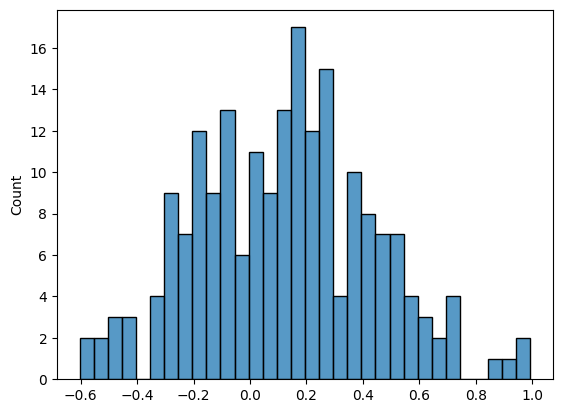

In [185]:
dataset = LmdbDataset({"src": "set_example_train/val.lmdb"})
db = [data['Form'] for data in dataset]
sns.histplot(db, binwidth=0.05)

print(f"{'Mean:':<10}{np.mean(db):.4f}")
print(f"{'Std Dev:':<10}{np.std(db):.4f}")
print(f"{'Min:':<10}{np.min(db):.4f}")
print(f"{'Max:':<10}{np.max(db):.4f}")

Mean:     0.1631
Std Dev:  0.3848
Min:      -0.6750
Max:      1.4244


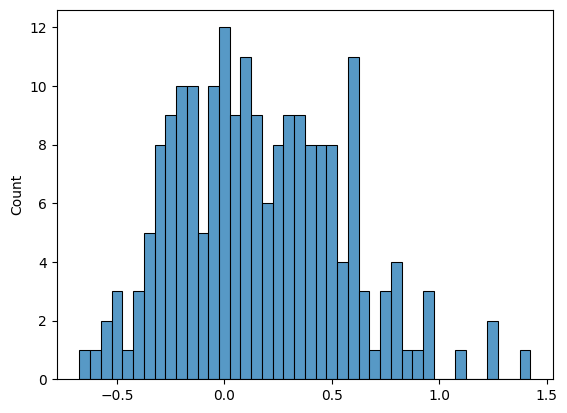

In [186]:
dataset = LmdbDataset({"src": "set_example_train/test.lmdb"})
db = [data['Form'] for data in dataset]
sns.histplot(db, binwidth=0.05)

print(f"{'Mean:':<10}{np.mean(db):.4f}")
print(f"{'Std Dev:':<10}{np.std(db):.4f}")
print(f"{'Min:':<10}{np.min(db):.4f}")
print(f"{'Max:':<10}{np.max(db):.4f}")

## Generate lmdb database for application dataset
Here, the application lmdb dataset is crreated to which the trained model will be applied. 

The method is similar to the generation of train/val/test sets. 

For application dataset, csv containing cell vecotrs, atoms positions and atom numbers are needed.

Here, we used UUID to label compounds, other labels such as compound name and formula can also be used.

In [187]:
compounds_df = pd.read_csv('./database_example_apply.csv', index_col=0, )
compounds_df.head(4)

,composition,UUID,cell,positions,numbers
8025,Cr2ScGa,35b02046-e21d-4f06-aaf9-0b608febaa1c,"[[3.15357838, 3.15357838, -0.0], [-3.15357838,...","[[0.5, 0.0, 0.25], [0.0, 0.5, 0.75000000000000...",[24 24 24 24 21 21 31 31]
5775,V2MnPb,acd92db5-cde1-4835-b31a-aa00358153c1,"[[2.75017099, 2.75017099, -0.0], [-2.75017099,...","[[0.5, 0.0, 0.25], [0.0, 0.5, 0.75000000000000...",[23 23 23 23 25 25 82 82]
60302,La2MnGa,6b5f6573-5d86-496c-a986-85196aade676,"[[-0.0, 3.76336882, 3.76336882], [3.76336882, ...","[[0.25, 0.25, 0.25], [0.75, 0.75, 0.75], [0.5,...",[57 57 25 31]
33538,MoPdSb,315f25de-a1b8-4472-ba6a-13fecce86378,"[[3.14895174, 3.14895174, -0.0], [-3.14895174,...","[[0.5, 0.0, 0.25], [0.0, 0.5, 0.75000000000000...",[42 42 46 46 51 51]


In [189]:
properties = {
    "UUID": "UUID",
} 
atoms_list = db_to_atomslist(compounds_df, properties=properties)
split_set  = {'apply' : atoms_list}
split_set_to_lmdb(split_set, properties, dir_name='set_example_apply')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 3929.51it/s]
